# Unit 2 – Pairwise Distance Matrix Computation
### Student: 2547115 | Subject: Machine Learning

---

## Q2. Demonstrate distance matrix computation using any 2 distance calculation methods.

### Objective
We will compute the pairwise distance matrix of the **Lab 2 Student Survey Dataset** using:
1. **Euclidean Distance** (`metric='euclidean'`)
2. **Manhattan Distance** (`metric='cityblock'`)

We will preprocess the numeric data, compute the matrices using `sklearn.metrics.pairwise_distances`, visualize them with simple heatmaps, and compare them side-by-side.

### Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.preprocessing import StandardScaler

print('Libraries loaded successfully!')

Libraries loaded successfully!


### Step 2: Load the Lab 2 Survey Dataset

In [2]:
df = pd.read_excel('../LAB_2/lab2 data.xlsx')
print('Original dataset shape:', df.shape)
df.head()

Original dataset shape: (163, 14)


,Timestamp,Reg No,Job role that you are interested in,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),your CIA % of last semester,your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,2024-12-04 20:31:09,2341338,Data Scientist,3 LPA,1Cr,20 LPA,Deolite,3.0,4,20 LPA,0.6,0.62,0.77,Industry
1,2024-12-04 20:33:07,2341310,Data Scientist,5,NaN,NaN,DE Shaw,3.0,2,11,67,60,97,Industry
2,2024-12-04 20:39:43,2341311,Data Scientist,7 LPA,15 LPA,8 LPA,DE Shaw,3.0,4,5 LPA,80,80,99,Research
3,2024-12-04 20:40:37,2341324,Data Scientist,3 LPA,25 LPA,10 LPA,DE Shaw,NaN,3,20,75,70,95,Research
4,2024-12-04 20:41:51,2341324,Business Analyst,2,50,25,Deolite,3.0,3,20,65,76,96,Industry


### Step 3: Simple Preprocessing & Feature Selection

In [3]:
# 1. Select the numeric columns of interest
features = [
    'Rate your contribution towards extra curricular activities',
    'Rate your technical competencies',
    'What are your package expectations (LPA)',
    'your CIA % of last semester',
    'your GPA of last semester',
    'Your maximum attendance % till last semester'
]

# 2. Clean and convert to numeric values
df_clean = df[features].copy()
for col in df_clean.columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Fix decimal entries in attendance (e.g., 0.95 -> 95)
df_clean['Your maximum attendance % till last semester'] = df_clean['Your maximum attendance % till last semester'].apply(
    lambda x: x * 100 if pd.notna(x) and x < 1.5 else x
)

# 3. Drop rows with missing values
df_clean = df_clean.dropna().reset_index(drop=True)
print('Cleaned dataset shape:', df_clean.shape)

Cleaned dataset shape: (104, 6)


### Step 4: Standardize the Features
Scaling is required because metrics like Package Expectation and CIA % have different scales. StandardScaler transforms each feature to have a mean of 0 and variance of 1.

In [4]:
scaler = StandardScaler()
X = scaler.fit_transform(df_clean)
print('Data scaled successfully.')

Data scaled successfully.


### Step 5: Method 1 — Compute Euclidean Distance Matrix
Euclidean distance measures the straight-line distance between two points in multidimensional space:
$$d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$

In [5]:
D_euclidean = pairwise_distances(X, metric='euclidean')
print('Euclidean distance matrix shape:', D_euclidean.shape)
print('Example matrix (first 5x5 students):')
print(np.round(D_euclidean[:5, :5], 3))

Euclidean distance matrix shape: (104, 104)
Example matrix (first 5x5 students):
[[0.    1.274 0.586 4.007 2.653]
 [1.274 0.    1.359 3.005 1.58 ]
 [0.586 1.359 0.    3.992 2.574]
 [4.007 3.005 3.992 0.    1.556]
 [2.653 1.58  2.574 1.556 0.   ]]


### Step 6: Method 2 — Compute Manhattan Distance Matrix
Manhattan distance is the sum of the absolute differences across all dimensions:
$$d(x, y) = \sum_{i=1}^{n} |x_i - y_i|$$

In [6]:
D_manhattan = pairwise_distances(X, metric='cityblock')
print('Manhattan distance matrix shape:', D_manhattan.shape)
print('Example matrix (first 5x5 students):')
print(np.round(D_manhattan[:5, :5], 3))

Manhattan distance matrix shape: (104, 104)
Example matrix (first 5x5 students):
[[0.    1.886 0.923 6.279 4.379]
 [1.886 0.    2.275 4.878 2.977]
 [0.923 2.275 0.    6.265 4.106]
 [6.279 4.878 6.265 0.    2.895]
 [4.379 2.977 4.106 2.895 0.   ]]


### Step 7: Visualize Both Distance Matrices Side-by-Side

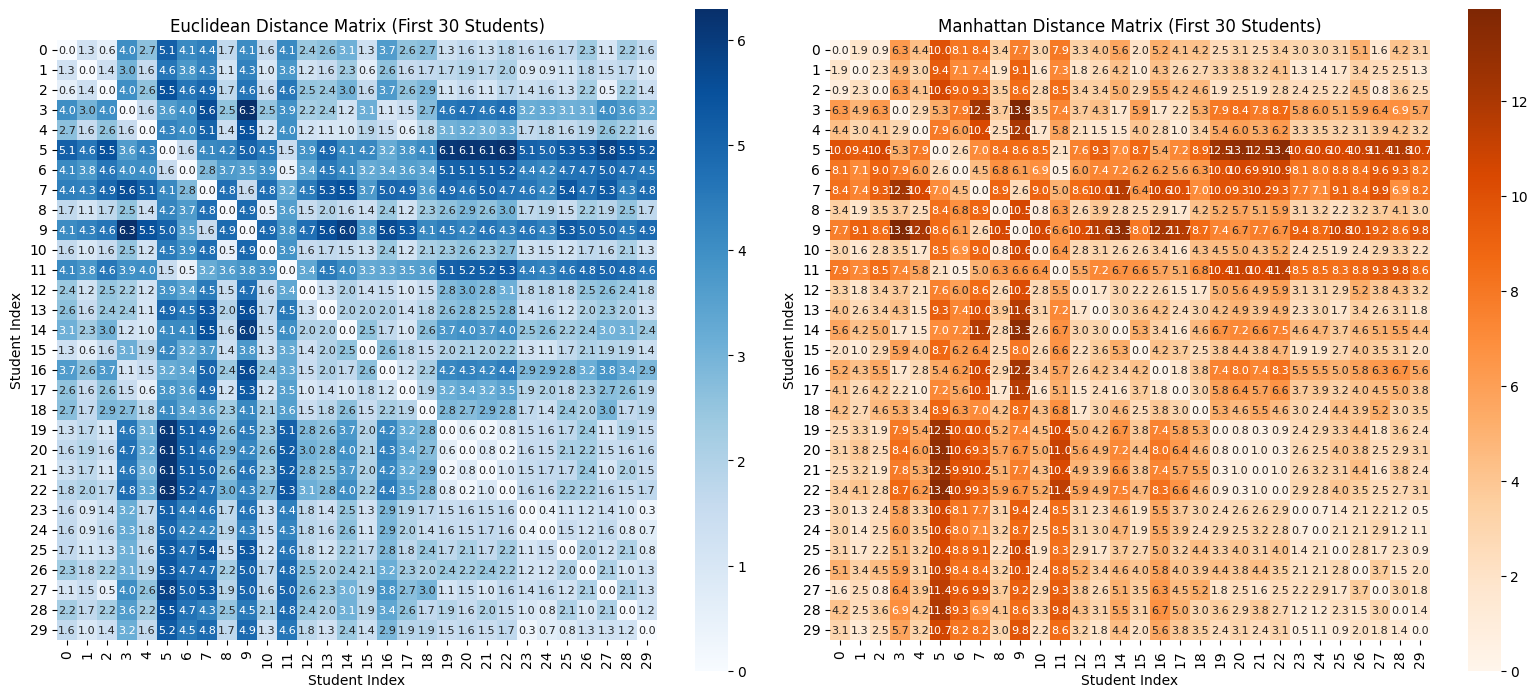

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# We visualize the first 30 students to make the heatmap clear and readable
N = 30

# Euclidean Heatmap
sns.heatmap(D_euclidean[:N, :N], ax=axes[0], cmap='Blues', annot=True, fmt='.1f', annot_kws={'size': 8}, square=True)
axes[0].set_title('Euclidean Distance Matrix (First 30 Students)')
axes[0].set_xlabel('Student Index')
axes[0].set_ylabel('Student Index')

# Manhattan Heatmap
sns.heatmap(D_manhattan[:N, :N], ax=axes[1], cmap='Oranges', annot=True, fmt='.1f', annot_kws={'size': 8}, square=True)
axes[1].set_title('Manhattan Distance Matrix (First 30 Students)')
axes[1].set_xlabel('Student Index')
axes[1].set_ylabel('Student Index')

plt.tight_layout()
plt.show()

### Step 8: Comparison & Discussion

In [8]:
# Extract upper triangles to compare unique pairs
euc_tri = D_euclidean[np.triu_indices_from(D_euclidean, k=1)]
man_tri = D_manhattan[np.triu_indices_from(D_manhattan, k=1)]

print('--- Statistical Summary ---')
print(f'Euclidean Distances - Min: {euc_tri.min():.2f}, Max: {euc_tri.max():.2f}, Mean: {euc_tri.mean():.2f}')
print(f'Manhattan Distances - Min: {man_tri.min():.2f}, Max: {man_tri.max():.2f}, Mean: {man_tri.mean():.2f}')

# Correlation
correlation = np.corrcoef(euc_tri, man_tri)[0, 1]
print(f'Pearson Correlation between the two distance types: {correlation:.4f}')
print('High correlation suggests that both distance methods preserve similar geometric patterns in this dataset.')

--- Statistical Summary ---
Euclidean Distances - Min: 0.04, Max: 10.56, Mean: 3.16
Manhattan Distances - Min: 0.05, Max: 18.43, Mean: 5.71
Pearson Correlation between the two distance types: 0.9566
High correlation suggests that both distance methods preserve similar geometric patterns in this dataset.
